<a target="_blank" href="https://colab.research.google.com/github/taobrienlbl/advanced_earth_science_data_analysis/blob/fall_2025_iub/content/lessons/04_digging_further_into_data_wrangling/04_estimating_building_height.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Exercise: Estimating Building Height with Pressure

This exercise aims to build on your knowledge of the big-four data science libraries to use Kestrel atmospheric measurement devices to estimate the height difference between the ground floor and sixth floor of the Geology building.

## Background

Air pressure monotonically decreases with height in the atmosphere.  This is simply due to the fact that *air pressure is a measure of the weight of everything above*.  So higher up in the atmosphere there is less atmosphere (weight) above, and pressure decreases.

One of the basic principles of fluid dynamics is that a *pressure gradient*--a change in pressure over some distance--exerts a net force on the fluid that, in the absence of other forces, would cause the fluid to move.  So why then does the atmosphere not flow away to space in response to this pressure gradient?

To a very good approximation, the atmosphere is in *hydrostatic balance*, meaning that the vertical pressure gradient is balanced by the force of gravity on the air; gravity effectively nullifies the vertical pressure gradient force.  This leads to one of the most essential equations in atmospheric science:

$$ \frac{\partial p}{\partial z} = -\rho g$$

where $p$ is the atmospheric pressure, $z$ is height away from the surface, $\rho$ is air density, and $g$ is the gravitational acceleration (we'll use $g \approx 9.806~\text{m s}^{-2}$ here).

If we combine this with the ideal gas law (written in a form that is convenient for atmospheric gasses, where $R_d \approx 287~\text{J kg}^{-1}\text{K}^{-1}$ represents a constant for air with the composition of Earth's atmosphere), we get a differential equation for pressure.

$$\text{Ideal gas law: }~p = \rho R_d T \to $$

$$ \frac{\partial p}{\partial z} = - \frac{p g}{R_d T} $$

We can approximate the derivatives in this equation using finite differences: $\partial p/\partial z \to \Delta p / \Delta z$, where $\Delta$ represents a (presumably small) difference between two pressure or height measurements.  We can then use this to solve for the change in height as a function of changes in pressure:

$$ \Delta z \approx - \frac{R_d T}{g} \frac{\Delta p}{p}$$

## Estimating height

Now imagine that we have a device that records pressure and temperature every second or so.  If you take that device and walk up a set of stairs, the recorded pressure will drop a bit for every second that you're ascending.  A pair of measurements taken at consecutive times can be used to estimate $\Delta p$, and the average of the two measurements can be used to estimate $p$ and $T$ over tha same time frame.  These values can be plugged in to the above formula to estimate the change in height between the two measurements.  The sum of all the changes in height then gives an estimate of the total change in height; we will have numerically integrated the differential equation that comes from combining hydrostatic balance and the ideal gas law.

### Instructions

1. form groups of two or three
1. acquaint yourself with the Kestrel measuring devices, and pair it to at least one of your phones using [Kestrel Link](https://kestrelinstruments.com/link-connectivity)
1. ensure that you can record measurements and export them to csv
1. take the kestrel device down to the ground floor of the Geology building; go to the lobby
1. start recording
1. either walk up the stairwell, or take the elevator, up to the 7th floor (you can only access this floor from the western stairwell)
1. end recording
1. export the data to a CSV file and add it to your course git folder (into a folder for lesson 04)
1. estimate the difference in height between the two floors using the method above (*hint*: you should use `pandas`, and you should be able to make a new column for the calculation of $\Delta p$ and $\Delta z$ for each measurement, and then use the `.sum()` method)

```{note}
If for some reason you need a data file to work with, here is the one used in the solution: [WEATHER_-_2414781_Sep_15_2023_2_56_14_PM.csv](https://raw.githubusercontent.com/taobrienlbl/advanced_earth_science_data_analysis/refs/heads/fall_2025_iub/content/lessons/04_digging_further_into_data_wrangling/WEATHER_-_2414781_Sep_15_2023_2_56_14_PM.csv)
```

In [41]:
# import statements
import numpy as np
import matplotlib.pyplot as plt
import scipy
import pandas as pd
import openpyxl

In [53]:
#import data from csv file that starts as bellow
#"Device Model","Kestrel DROP 3"
#"Serial Number","2497726"
#"FORMATTED DATE_TIME","Temperature","Relative Humidity","Station Pressure","Heat Index","Dew Point","Density Altitude","Data Type","Record name","Start time","Duration (H:M:S)","Location description","Location address","Location coordinates","Notes"
#"YYYY-MM-DD HH:MM:SS","°F","%","inHg","°F","°F","ft"
#"2025-09-19 02:45:06 PM","72.5","40.3","29.22","70.7","47.0","1824","session","Session - Sep 19, 2025_2:46:30 PM","Sep 19, 2025 / 2:45:02 PM","00:01:28","","","",""
#"2025-09-19 02:45:11 PM","72.6","40.0","29.22","70.7","46.9","1826","session"
#"2025-09-19 02:45:16 PM","72.9","40.9","29.21","71.2","47.8","1858","session"
#"2025-09-19 02:45:21 PM","73.1","43.2","29.21","71.4","49.4","1881","session"
data = pd.read_csv('EAS_-_2497726_Sep_19,_2025___2_46_30_PM.csv', skiprows=6, header=None)
data.columns = [
	"FORMATTED DATE_TIME", "Temperature", "Relative Humidity", "Station Pressure",
	"Heat Index", "Dew Point", "Density Altitude", "Data Type"
]
data = data.dropna()  # Remove rows with missing values
data['Station Pressure'] = (data['Station Pressure'].astype(float))*3386.39
data['Density Altitude'] = data['Density Altitude'].astype(float)
data['Temperature'] = (data['Temperature'].astype(float))
data['Relative Humidity'] = data['Relative Humidity'].astype(float)
data['Dew Point'] = data['Dew Point'].astype(float)
data['Heat Index'] = data['Heat Index'].astype(float)
data['FORMATTED DATE_TIME'] = pd.to_datetime(data['FORMATTED DATE_TIME'], format='%Y-%m-%d %I:%M:%S %p')
data = data.reset_index(drop=True)
data['Time (s)'] = (data['FORMATTED DATE_TIME'] - data['FORMATTED DATE_TIME'].iloc[0]).dt.total_seconds()
data = data[['Time (s)', 'Temperature', 'Relative Humidity', 'Station Pressure', 'Heat Index', 'Dew Point', 'Density Altitude']]

# Display the first few rows of the cleaned data
print(data.head())
print(data['Temperature'][1])









   Time (s)  Temperature  Relative Humidity  Station Pressure  Heat Index  \
0       0.0         72.6               40.0        98950.3158        70.7   
1       5.0         72.9               40.9        98916.4519        71.2   
2      10.0         73.1               43.2        98916.4519        71.4   
3      15.0         72.6               41.6        98916.4519        70.9   
4      20.0         73.5               40.6        98916.4519        71.6   

   Dew Point  Density Altitude  
0       46.9            1826.0  
1       47.8            1858.0  
2       49.4            1881.0  
3       48.0            1844.0  
4       48.1            1900.0  
72.9


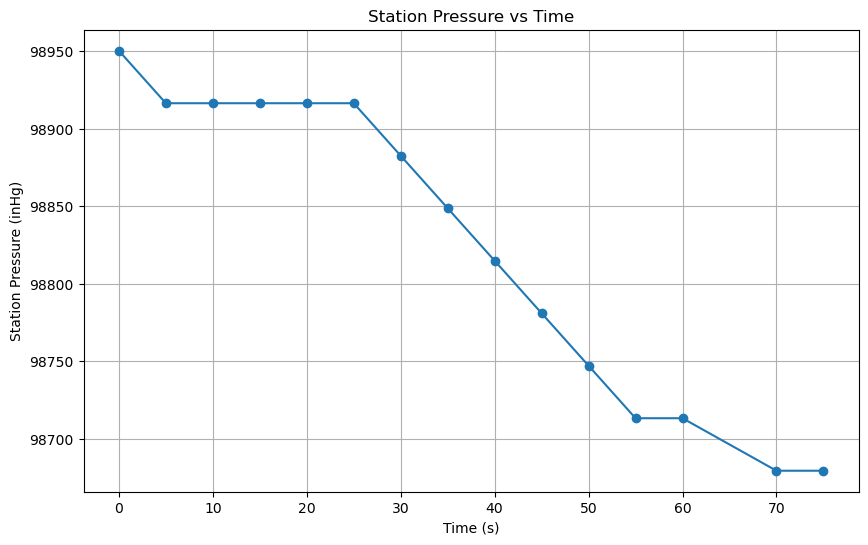

In [43]:
#plot data of pressure against time
plt.figure(figsize=(10, 6))
plt.plot(data['Time (s)'], data['Station Pressure'], marker='o', linestyle='-')
plt.title('Station Pressure vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Station Pressure (inHg)')
plt.grid()
plt.show()    

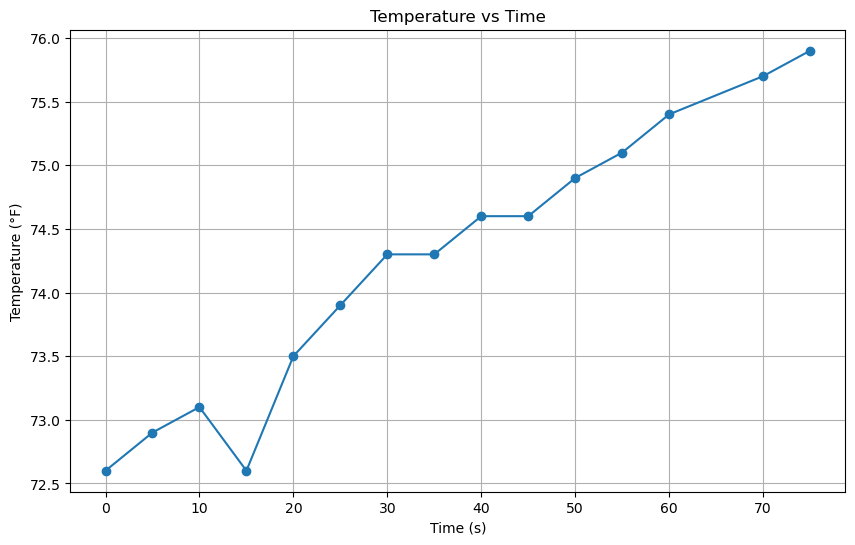

In [44]:
#plot temperature against time
plt.figure(figsize=(10, 6))
plt.plot(data['Time (s)'], data['Temperature'], marker='o', linestyle='-')
plt.title('Temperature vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°F)')
plt.grid()
plt.show()

270.9112000000023


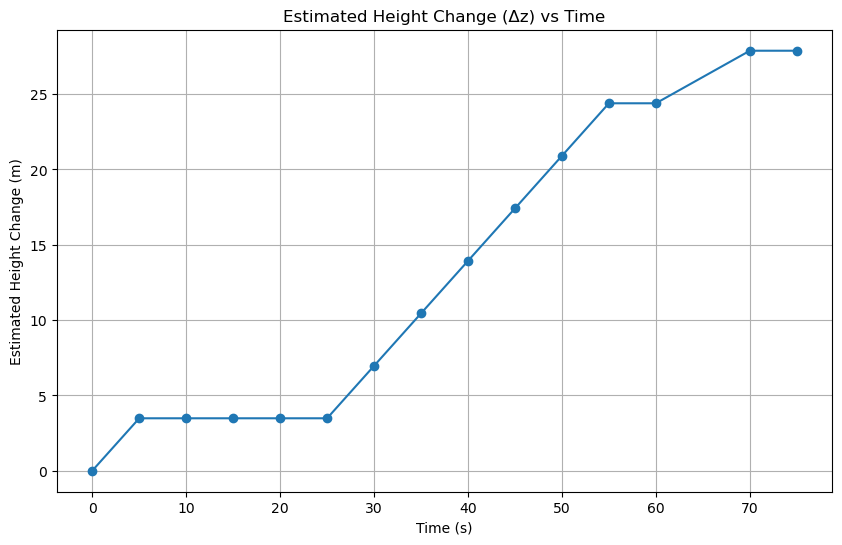

In [57]:
#plotting delta z from hydrostatic balance equation
R = 287.05  # J/(kg·K), specific gas constant for dry
g = 9.806  # m/s², acceleration due to gravity
T_avg = np.mean(data['Temperature']) + 273.15  # Convert to Kelvin
delta_P = data['Station Pressure'].iloc[0] - data['Station Pressure'][14]
print(delta_P)
delta_z = (R * T_avg / g) * np.log(data['Station Pressure'].iloc[0] / data['Station Pressure'])
plt.figure(figsize=(10, 6))
plt.plot(data['Time (s)'], delta_z, marker='o', linestyle='-')
plt.title('Estimated Height Change (Δz) vs Time')
plt.xlabel('Time (s)')
plt.ylabel('Estimated Height Change (m)')
plt.grid()
plt.show()


In [ ]:
#calculate delta z using sum function

R = 287.05  # J/(kg·K), specific gas constant for dry
g = 9.806 #acceleration due to gravity 
T = np.mean(data['Temperature'])+273.3
del_P = data['Station Pressure'][0] - data['Station Pressure'][14]

print(del_P)


270.9112000000023
